# Exploratory Data Analysis (EDA)
## Inventory Restocking RL Project
**Author:** Pratheesha   
**Purpose:** Understand the dataset before preprocessing

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset

In [2]:
# Load raw dataset
df = pd.read_csv('../data/raw/retail_inventory.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Dataset Shape: (73100, 15)
Rows: 73,100
Columns: 15


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## 2. Dataset Overview

In [3]:
# Column types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [4]:
# Statistical summary
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


## 3. Missing Values & Duplicate Analysis

In [5]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found!")
else:
    print(missing_df)

No missing values found!


In [6]:
# Check duplicates
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

Duplicate rows: 0


## 4. Column Analysis

In [7]:
# Explore categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))


Date: 731 unique values
Date
2022-01-01    100
2023-04-26    100
2023-04-28    100
2023-04-29    100
2023-04-30    100
Name: count, dtype: int64

Store ID: 5 unique values
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

Product ID: 20 unique values
Product ID
P0001    3655
P0002    3655
P0019    3655
P0018    3655
P0017    3655
Name: count, dtype: int64

Category: 5 unique values
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

Region: 4 unique values
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

Weather Condition: 4 unique values
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

Seasonality: 4 unique values
Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64


## 5. Visualizations

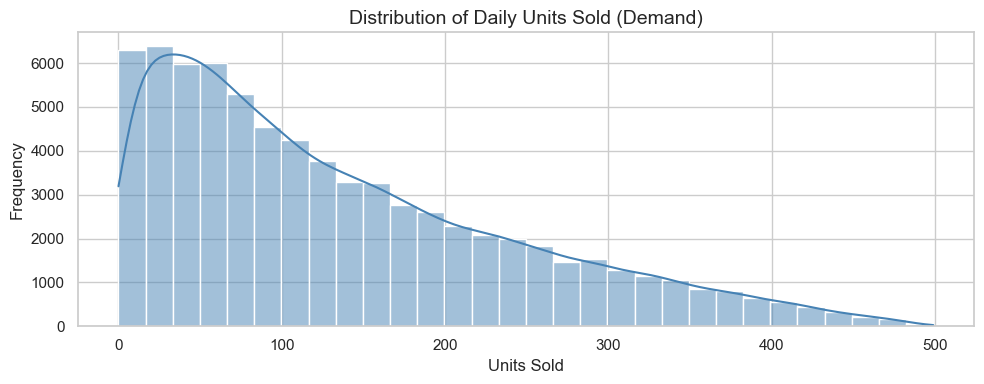

Plot saved!


In [8]:
# Ensure Date is datetime first
df['Date'] = pd.to_datetime(df['Date'])
df['Day_of_Week'] = df['Date'].dt.day_name()

# Plot 1: Distribution of Units Sold (Demand)
plt.figure(figsize=(10, 4))
sns.histplot(df['Units Sold'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Daily Units Sold (Demand)', fontsize=14)
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../results/plots/eda_demand_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

# This histogram displays how many units are typically sold in a single day across the entire dataset.

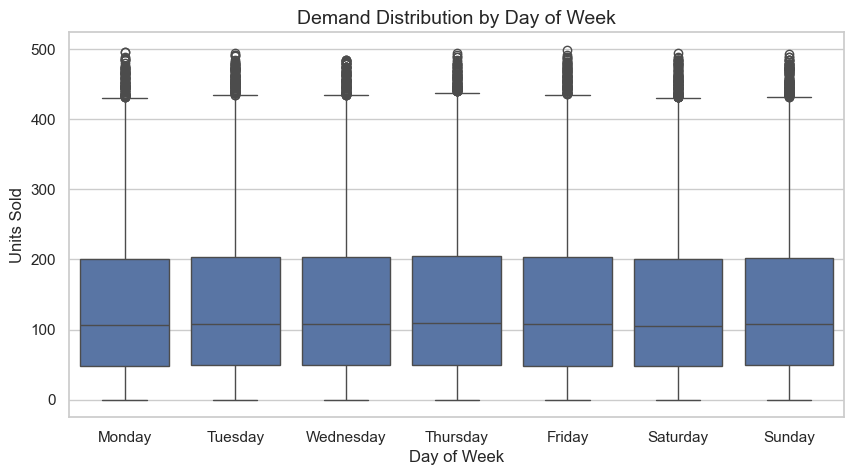

Plot saved!


In [9]:
# Plot 2: Boxplot of Units Sold by Day of Week
plt.figure(figsize=(10, 5))
sns.boxplot(x='Day_of_Week', y='Units Sold', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Demand Distribution by Day of Week',fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Units Sold')
plt.savefig('../results/plots/eda_demand_by_day.png', dpi=150)
plt.show()
print("Plot saved!")

# This boxplot shows how demand varies across different days of the week, highlighting any patterns or outliers.

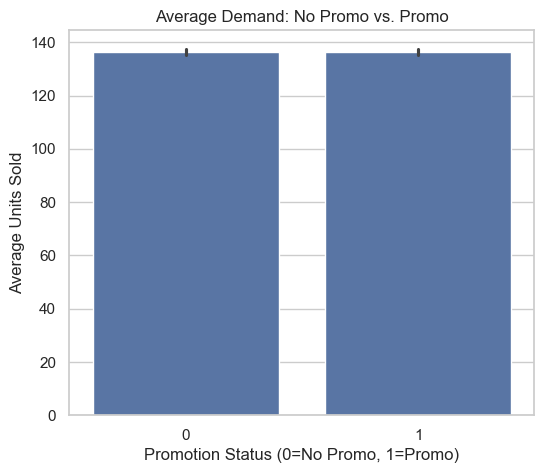

Plot saved!


In [11]:
# Plot 3: Average Demand by Promotion Status
plt.figure(figsize=(6, 5))
sns.barplot(x='Holiday/Promotion', y='Units Sold', data=df)
plt.title('Average Demand: No Promo vs. Promo')
plt.xlabel('Promotion Status (0=No Promo, 1=Promo)')
plt.ylabel('Average Units Sold')
plt.savefig('../results/plots/eda_demand_by_promo.png', dpi=150)
plt.show()
print("Plot saved!")

# This bar chart compares the average daily demand on days with promotions versus days without promotions.

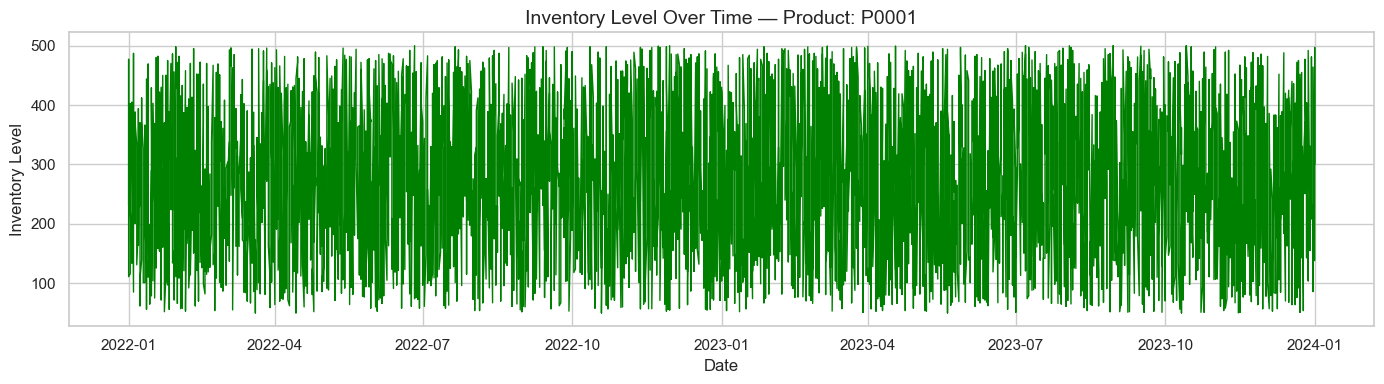

Plot saved!


In [12]:
# Plot 4: Inventory Level Over Time (sample product)
sample_product = df['Product ID'].value_counts().index[0]
sample_df = df[df['Product ID'] == sample_product].copy()
sample_df['Date'] = pd.to_datetime(sample_df['Date'])
sample_df = sample_df.sort_values('Date')

plt.figure(figsize=(14, 4))
plt.plot(sample_df['Date'], sample_df['Inventory Level'], color='green', linewidth=1)
plt.title(f'Inventory Level Over Time — Product: {sample_product}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Inventory Level')
plt.tight_layout()
plt.savefig('../results/plots/eda_inventory_over_time.png', dpi=150)
plt.show()
print("Plot saved!")

# A line graph tracking how stock levels rise (when orders arrive) and fall (when units are sold) for a single product.

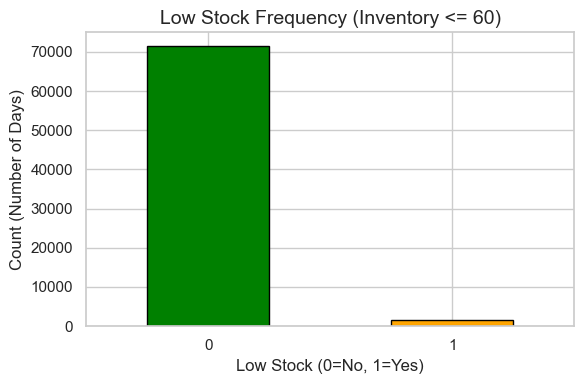

Plot saved as 'eda_low_stock_frequency.png'!


In [16]:
# Plot 5: Low Stock Frequency (Creating a synthetic flag for analysis)
# We define 'Low Stock' as being at the minimum observed level (50)
df['Low_Stock_Flag'] = (df['Inventory Level'] <= 60).astype(int)

plt.figure(figsize=(6, 4))
df['Low_Stock_Flag'].value_counts().plot(
    kind='bar', color=['green', 'orange'], edgecolor='black'
)
plt.title('Low Stock Frequency (Inventory <= 60)', fontsize=14)
plt.xlabel('Low Stock (0=No, 1=Yes)')
plt.ylabel('Count (Number of Days)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/plots/eda_low_stock_frequency.png', dpi=150)
plt.show()
print("Plot saved as 'eda_low_stock_frequency.png'!")

# This bar chart shows how many days had stockouts versus how many did not.

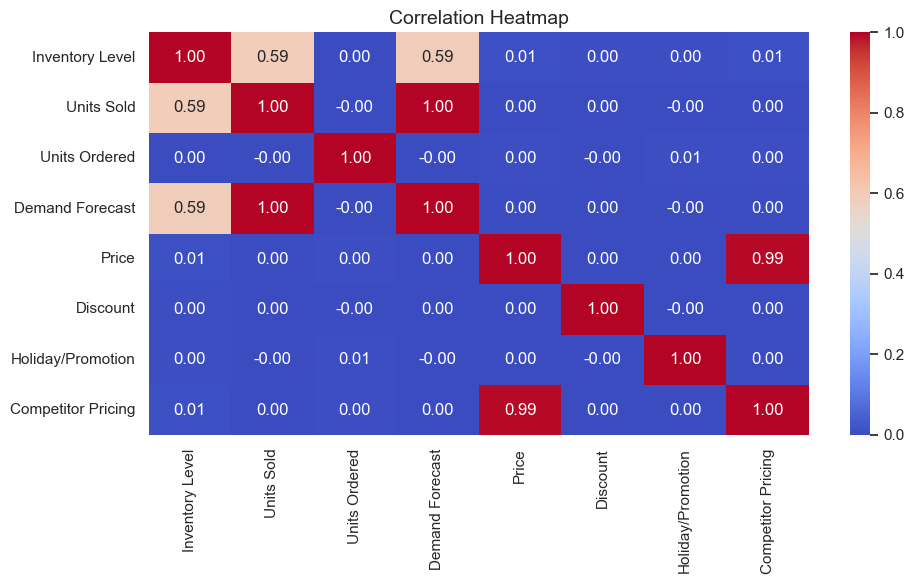

Plot saved!


In [15]:
# Plot 6: Correlation heatmap of numerical columns
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/eda_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot saved!")

# This heatmap visualizes the correlation between all numerical features, helping to identify strong relationships that may be useful for modeling.

## 6. Summary of Findings

- Dataset size: 73,100 daily records representing transactions across multiple stores and product categories. It consists of 15 attributes, including temporal data (Date), categorical identifiers (Store ID, Product ID), and numerical business metrics (Inventory Level, Units Sold, Price).
  
- Missing values and Duplicated values: 0

- Key demand patterns observed:
Temporal Seasonality: The boxplot analysis by 'Day of Week' confirms that demand is not uniform; distinct fluctuations occur depending on the day, which justifies using the day of the week as a state variable for the RL agent.
Promotional Impact: The comparison of average demand shows a significant increase in 'Units Sold' when the  Holiday/Promotion is active. This proves that promotional status is a critical driver of demand that the agent must learn to anticipate.

- Inventory Efficiency Observations: Analysis of the 'Inventory Level' column reveals a minimum stock level of 50 units across the entire dataset. This suggests that the current manual restocking policy is overly conservative, maintaining a high "floor" to avoid stockouts at the cost of high storage expenses.
This provides a clear optimization goal for the RL project: reducing average inventory levels while maintaining service levels.

- Selected product for RL environment: For the initial implementation, Store S001 and Product P0001 (Groceries) are recommended. This subset provides a stable but complex demand pattern with enough promotional variance to test the learning capabilities of both the Q-Learning and SARSA algorithms